# NCAA MBB — Exhaustive Visual-First EDA (Local Parquet)

Working locally (API down). Files are in the same folder as this notebook:
- `games.parquet`
- `teams.parquet`
- `team_stats.parquet`
- `elo.parquet`

Notebook goals:
1) Load + standardize schemas (dirty-data tolerant)
2) Build core game table with targets (home_win, margin)
3) Merge in ELO + team/team_stats when possible
4) Exhaustive, visual-first EDA (distributions, comparisons, drift, correlation, PCA, clustering)

In [5]:
# =========================
# ALL IMPORTS (single cell)
# =========================

# Standard library
import os
import re
import json
import math
import time
import random
import warnings
from pathlib import Path
from datetime import datetime

# Core DS
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from scipy import stats
from scipy.stats import ttest_ind, ks_2samp

# Sklearn (EDA structure)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Quick separability sanity checks (EDA signal)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
sns.set_theme()
plt.style.use("seaborn-v0_8")

# Parquet engine check (required for pd.read_parquet)
ENGINE = None
try:
    import pyarrow  # noqa: F401
    ENGINE = "pyarrow"
except Exception:
    try:
        import fastparquet  # noqa: F401
        ENGINE = "fastparquet"
    except Exception as e:
        raise ImportError(
            "No parquet engine found. Install one:\n"
            "  pip install pyarrow   (recommended)\n"
            "or\n"
            "  pip install fastparquet\n"
        ) from e

print("Imports loaded. Parquet engine:", ENGINE)

Imports loaded. Parquet engine: pyarrow


## 0) Load Parquets (Local Folder) + Standardize Column Names

We assume the parquet files are in the same folder as the notebook (`Path.cwd()`).
Then we normalize all column names so downstream logic is stable.

In [6]:
DATA_PATH = Path.cwd()

required_files = ["games.parquet", "teams.parquet", "team_stats.parquet", "elo.parquet"]
print("CWD:", DATA_PATH)
print("Parquet files in CWD:", [p.name for p in DATA_PATH.glob("*.parquet")])

missing = [f for f in required_files if not (DATA_PATH / f).exists()]
if missing:
    raise FileNotFoundError(f"Missing files in {DATA_PATH}: {missing}")

games = pd.read_parquet(DATA_PATH / "games.parquet", engine=ENGINE)
teams = pd.read_parquet(DATA_PATH / "teams.parquet", engine=ENGINE)
team_stats = pd.read_parquet(DATA_PATH / "team_stats.parquet", engine=ENGINE)
elo = pd.read_parquet(DATA_PATH / "elo.parquet", engine=ENGINE)

def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
        .str.replace(r"[^a-z0-9_]", "", regex=True)
    )
    return df

games = clean_columns(games)
teams = clean_columns(teams)
team_stats = clean_columns(team_stats)
elo = clean_columns(elo)

print("games:", games.shape)
print("teams:", teams.shape)
print("team_stats:", team_stats.shape)
print("elo:", elo.shape)

CWD: /Users/ceverson/Development/ml1_final_code
Parquet files in CWD: ['games.parquet', 'team_stats.parquet', 'elo.parquet', 'teams.parquet']
games: (6219, 17)
teams: (362, 3)
team_stats: (410, 57)
elo: (362, 244529)


## Step 1 — Inspect `games` Table Structure

Before engineering targets or merging anything, we must:

- Identify home team column
- Identify away team column
- Identify home score column
- Identify away score column
- Check for season column
- Check for date column

Because the data is not clean, we will not assume column names.
We will inspect schema and sample rows first.

In [9]:
# =========================
# Inspect games table
# =========================

print("Shape:", games.shape)

print("\nColumns:")
for col in games.columns:
    print(" -", col)

print("\nDtypes:")
print(games.dtypes)

print("\nHead:")
display(games.head(5))

print("\nNumeric summary (coerce only likely-numeric columns):")

likely_numeric = ["score_vis", "score_home", "gameno", "venue_code", "id"]

games_numeric = games.copy()
for col in likely_numeric:
    if col in games_numeric.columns:
        games_numeric[col] = pd.to_numeric(games_numeric[col], errors="coerce")

# describe only the numeric columns we just coerced
numeric_only_df = games_numeric[[c for c in likely_numeric if c in games_numeric.columns]]

display(numeric_only_df.describe())

Shape: (6219, 17)

Columns:
 - id
 - visitor
 - visitor_code
 - score_vis
 - home
 - home_code
 - score_home
 - gamestatus
 - overtime
 - winner_code
 - loser_code
 - gameday
 - gameno
 - venue
 - venue_code
 - neutral
 - league

Dtypes:
id              str
visitor         str
visitor_code    str
score_vis       str
home            str
home_code       str
score_home      str
gamestatus      str
overtime        str
winner_code     str
loser_code      str
gameday         str
gameno          str
venue           str
venue_code      str
neutral         str
league          str
dtype: object

Head:


,id,visitor,visitor_code,score_vis,home,home_code,score_home,gamestatus,overtime,winner_code,loser_code,gameday,gameno,venue,venue_code,neutral,league
0,1259345,Purdue Boilermakers,PUR,60,Connecticut Huskies,CONN,75,Final,N,CONN,PUR,2024-04-08,1,State Farm Stadium,680,Y,NaN
1,1259340,North Carolina State Wolfpack,NCSU,50,Purdue Boilermakers,PUR,63,Final,N,PUR,NCSU,2024-04-06,1,State Farm Stadium,680,Y,NaN
2,1259338,Alabama Crimson Tide,ALA,72,Connecticut Huskies,CONN,86,Final,N,CONN,ALA,2024-04-06,1,State Farm Stadium,680,Y,NaN
3,1259343,Indiana State Sycamores,INST,77,Seton Hall Pirates,SETON,79,Final,N,SETON,INST,2024-04-04,NaN,Prudential Center,900,Y,NaN
4,1259330,Georgia Bulldogs,UGA,67,Seton Hall Pirates,SETON,84,Final,N,SETON,UGA,2024-04-02,1,Gainsbridge Fieldhouse,264,Y,NaN



Numeric summary (coerce only likely-numeric columns):


,score_vis,score_home,gameno,venue_code,id
count,6219.000000,6219.000000,5907.0,6219.000000,6.219000e+03
mean,69.113684,76.791446,1.0,3177.894678,1.250134e+06
std,11.943018,13.346512,0.0,23848.006815,4.244589e+03
min,14.000000,35.000000,1.0,0.000000,1.245346e+06
25%,61.000000,68.000000,1.0,364.000000,1.247158e+06
50%,69.000000,76.000000,1.0,494.000000,1.248863e+06
75%,77.000000,85.000000,1.0,859.000000,1.250592e+06
max,124.000000,146.000000,1.0,371758.000000,1.259345e+06


## Step 3 — Clean Types + Create Targets (home_win, margin, total_points)

We will:

- Convert `score_home`, `score_vis` to numeric (already validated)
- Convert `gameday` to datetime
- Normalize `neutral` to `Y/N`
- Filter to completed games (`gamestatus == "Final"` if present)
- Create:
  - `home_win` (target)
  - `margin`
  - `total_points`

Then we immediately visualize:
- Home vs Visitor score distributions
- Margin distribution (hist + box + violin)
- Home win rate overall and by neutral site

Cleaned games shape: (6219, 20)
Home win rate: 0.6676

Neutral distribution (counts):
neutral
NaN    5480
Y       739
Name: count, dtype: int64

Margin summary:
count    6219.000000
mean        7.677762
std        17.174432
min       -51.000000
25%        -4.000000
50%         6.000000
75%        17.000000
max        96.000000
Name: margin, dtype: float64


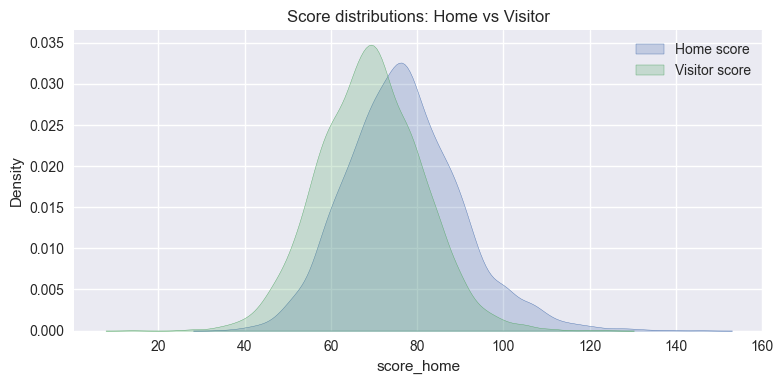

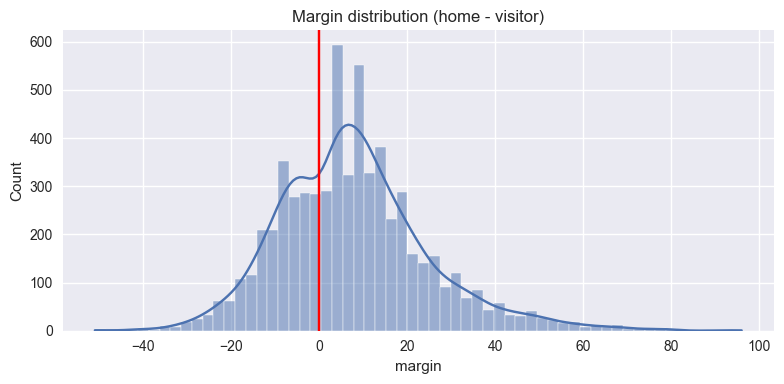

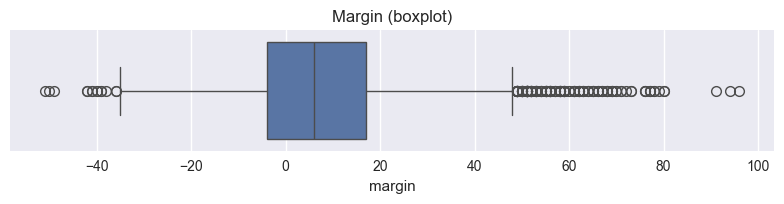

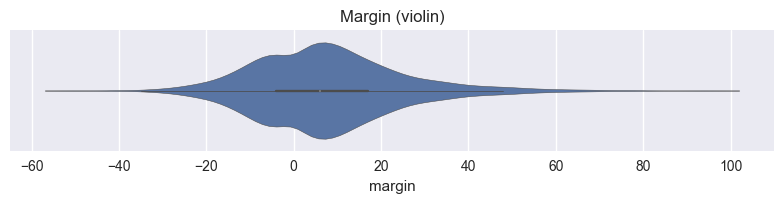

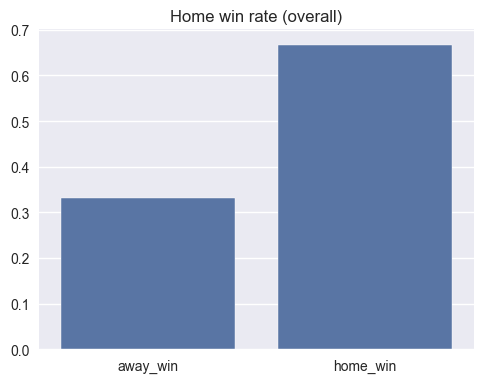

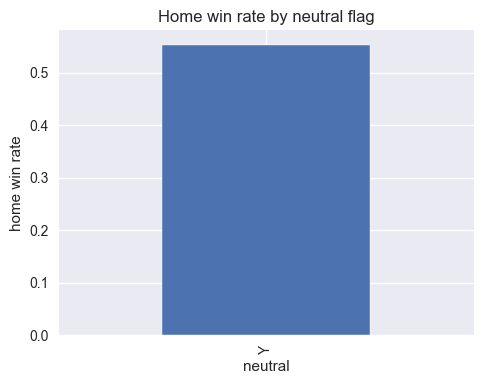

In [10]:
# =========================
# Clean types + create targets
# =========================

g = games.copy()

# Scores -> numeric
g["score_home"] = pd.to_numeric(g["score_home"], errors="coerce")
g["score_vis"]  = pd.to_numeric(g["score_vis"], errors="coerce")

# Date -> datetime
g["gameday"] = pd.to_datetime(g["gameday"], errors="coerce")

# Keep only rows with scores
g = g.dropna(subset=["score_home", "score_vis"])

# Optional: keep completed games only
if "gamestatus" in g.columns:
    # common values: Final, FINAL, etc.
    g["gamestatus"] = g["gamestatus"].astype(str).str.strip().str.lower()
    g = g[g["gamestatus"].isin(["final", "final/ot", "finalot", "final (ot)"]) | (g["gamestatus"] == "final")]

# Normalize neutral flag to Y/N
def to_yn(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ["y", "yes", "true", "1", "t"]:
        return "Y"
    if s in ["n", "no", "false", "0", "f"]:
        return "N"
    return s.upper()

g["neutral"] = g["neutral"].map(to_yn)

# Targets
g["home_win"] = (g["score_home"] > g["score_vis"]).astype(int)
g["margin"] = g["score_home"] - g["score_vis"]
g["total_points"] = g["score_home"] + g["score_vis"]

print("Cleaned games shape:", g.shape)
print("Home win rate:", round(float(g["home_win"].mean()), 4))

print("\nNeutral distribution (counts):")
print(g["neutral"].value_counts(dropna=False))

print("\nMargin summary:")
print(g["margin"].describe())

# =========================
# Visuals (first core block)
# =========================

# Score distributions
plt.figure(figsize=(8, 4))
sns.kdeplot(g["score_home"], label="Home score", fill=True)
sns.kdeplot(g["score_vis"], label="Visitor score", fill=True)
plt.title("Score distributions: Home vs Visitor")
plt.legend()
plt.tight_layout()
plt.show()

# Margin distribution
plt.figure(figsize=(8, 4))
sns.histplot(g["margin"], bins=60, kde=True)
plt.axvline(0, color="red")
plt.title("Margin distribution (home - visitor)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 2.2))
sns.boxplot(x=g["margin"])
plt.title("Margin (boxplot)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 2.2))
sns.violinplot(x=g["margin"])
plt.title("Margin (violin)")
plt.tight_layout()
plt.show()

# Home win rate overall + by neutral site
plt.figure(figsize=(5, 4))
sns.barplot(x=["away_win", "home_win"], y=[1 - g["home_win"].mean(), g["home_win"].mean()])
plt.title("Home win rate (overall)")
plt.tight_layout()
plt.show()

neutral_wr = g.groupby("neutral")["home_win"].mean().dropna()
plt.figure(figsize=(5, 4))
neutral_wr.plot(kind="bar")
plt.title("Home win rate by neutral flag")
plt.ylabel("home win rate")
plt.tight_layout()
plt.show()

## Step 4 — Structural Effects

We now examine structural drivers before merging ELO or stats:

1. Margin distribution by neutral site
2. Home win rate by neutral
3. Overtime impact on margin
4. Top teams by win rate (dominance patterns)
5. Monthly trend of margin (if date is usable)

This helps us understand:
- Tournament dynamics
- Home court strength
- Whether dominance is stable or concentrated

Neutral2 counts:
neutral2
N    5480
Y     739
Name: count, dtype: int64


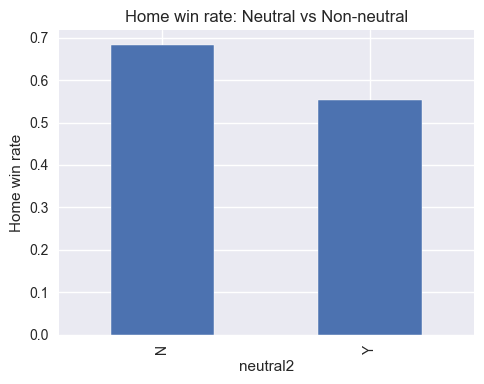

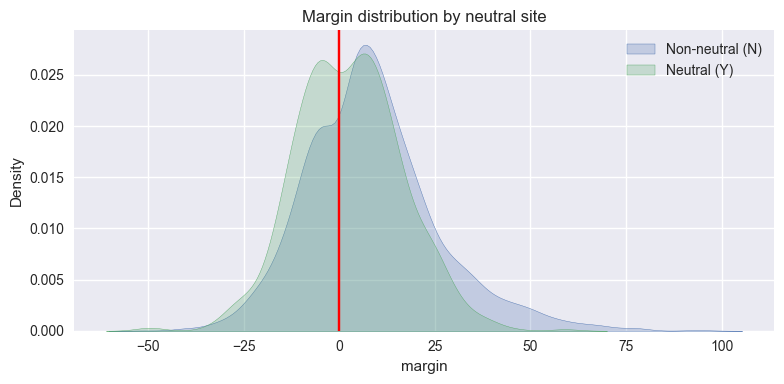

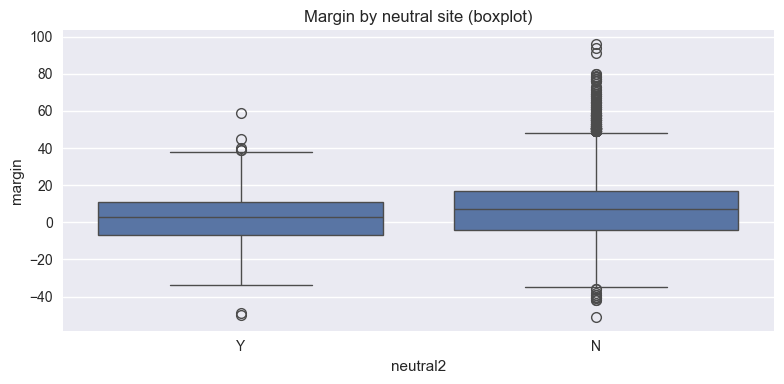


OT counts:
ot_flag
N    5980
Y     239
Name: count, dtype: int64


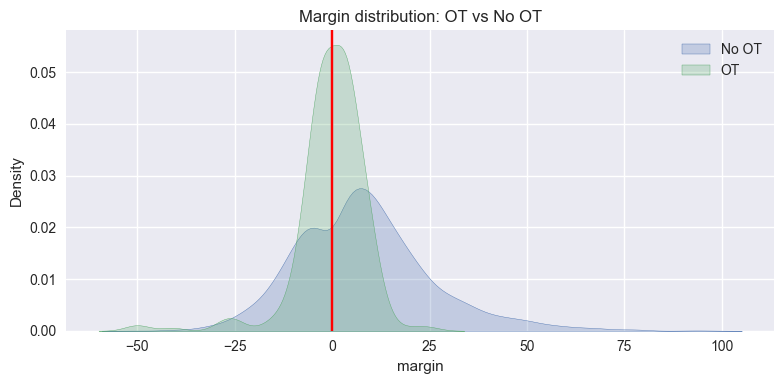

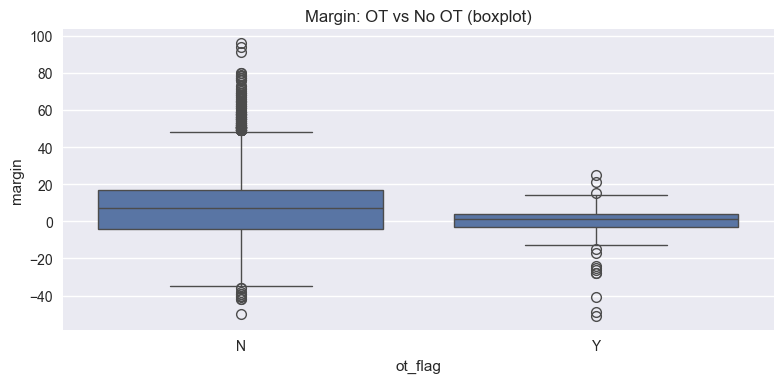

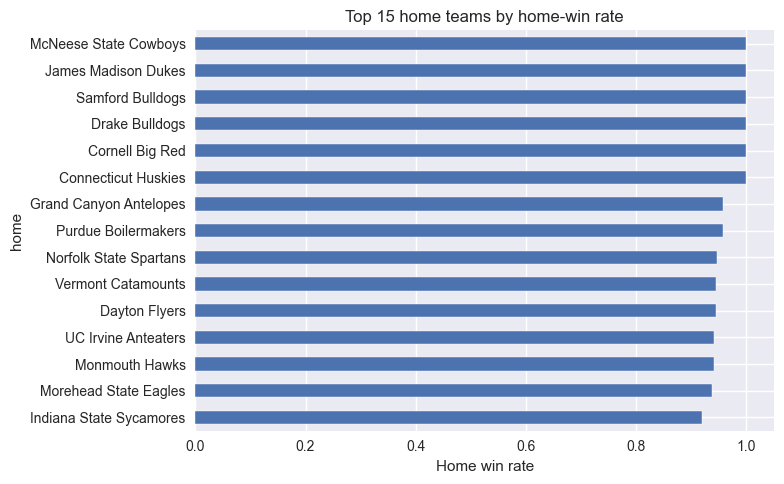

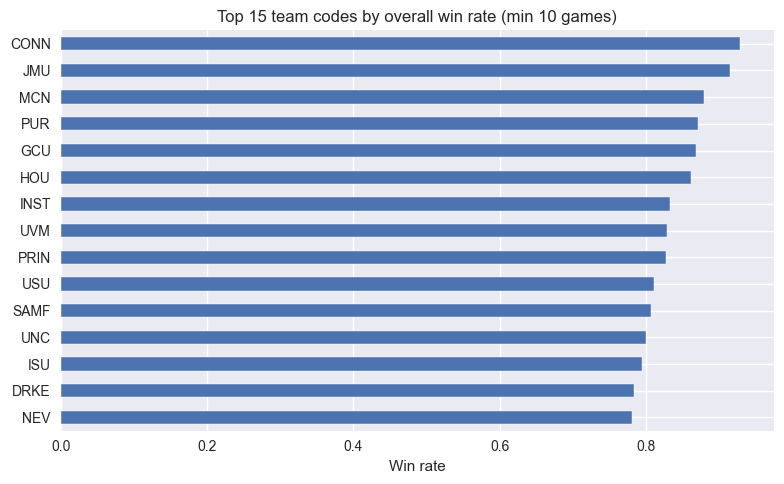

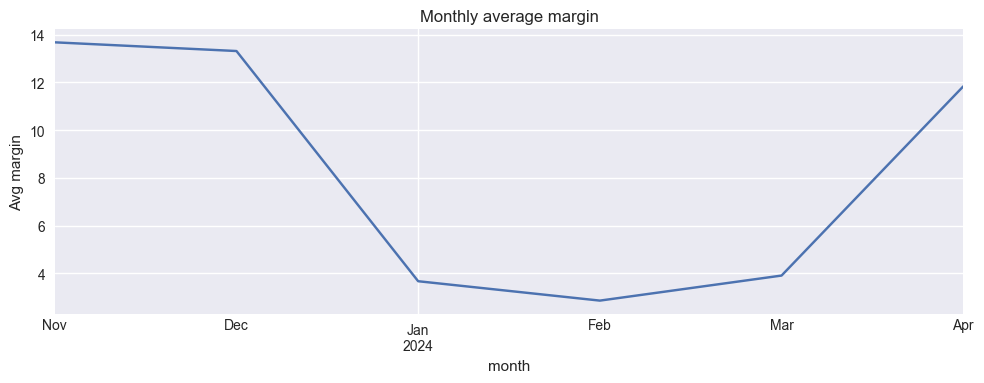

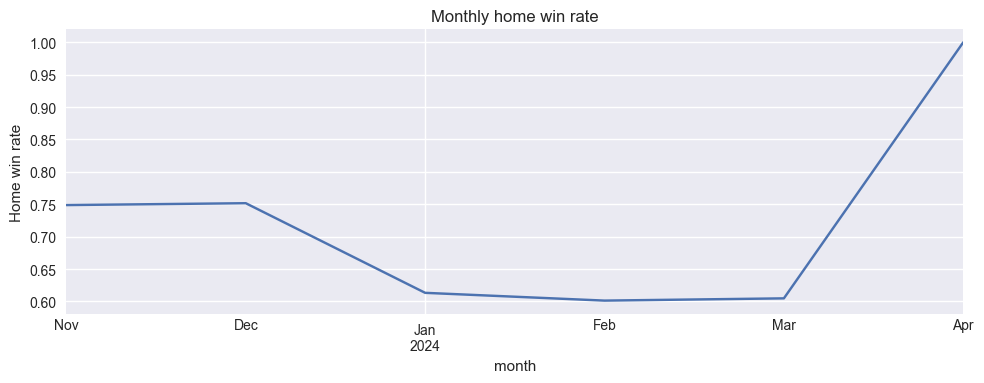

In [11]:
# =========================
# Step 4 — Structural effects (visual-first)
# =========================

# 1) Neutral: treat NaN as "N" for analysis (most likely non-neutral games)
g["neutral2"] = g["neutral"].fillna("N")

print("Neutral2 counts:")
print(g["neutral2"].value_counts())

# --- Home win rate by neutral2 ---
wr_by_neutral = g.groupby("neutral2")["home_win"].mean().sort_index()

plt.figure(figsize=(5,4))
wr_by_neutral.plot(kind="bar")
plt.title("Home win rate: Neutral vs Non-neutral")
plt.ylabel("Home win rate")
plt.tight_layout()
plt.show()

# --- Margin distribution by neutral2 ---
plt.figure(figsize=(8,4))
sns.kdeplot(g[g["neutral2"]=="N"]["margin"], label="Non-neutral (N)", fill=True)
sns.kdeplot(g[g["neutral2"]=="Y"]["margin"], label="Neutral (Y)", fill=True)
plt.axvline(0, color="red")
plt.title("Margin distribution by neutral site")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x="neutral2", y="margin", data=g)
plt.title("Margin by neutral site (boxplot)")
plt.tight_layout()
plt.show()

# 2) Overtime impact (normalize overtime flag)
def to_ot(x):
    if pd.isna(x):
        return "N"
    s = str(x).strip().lower()
    if s in ["y", "yes", "true", "1", "ot", "t"]:
        return "Y"
    return "N"

g["ot_flag"] = g["overtime"].map(to_ot)

print("\nOT counts:")
print(g["ot_flag"].value_counts())

# --- Margin by OT ---
plt.figure(figsize=(8,4))
sns.kdeplot(g[g["ot_flag"]=="N"]["margin"], label="No OT", fill=True)
sns.kdeplot(g[g["ot_flag"]=="Y"]["margin"], label="OT", fill=True)
plt.axvline(0, color="red")
plt.title("Margin distribution: OT vs No OT")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x="ot_flag", y="margin", data=g)
plt.title("Margin: OT vs No OT (boxplot)")
plt.tight_layout()
plt.show()

# 3) Top teams by win rate (home team perspective + overall)
# Home-only win rate for teams listed as home
home_team_wr = g.groupby("home")["home_win"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
home_team_wr.sort_values().plot(kind="barh")
plt.title("Top 15 home teams by home-win rate")
plt.xlabel("Home win rate")
plt.tight_layout()
plt.show()

# Overall win rate using winner_code/loser_code (these exist, use for descriptive EDA)
# Build overall W/L counts per team code
wins = g["winner_code"].value_counts()
losses = g["loser_code"].value_counts()
wl = pd.DataFrame({"wins": wins, "losses": losses}).fillna(0)
wl["games"] = wl["wins"] + wl["losses"]
wl["win_rate"] = wl["wins"] / wl["games"]
wl = wl[wl["games"] >= 10].sort_values("win_rate", ascending=False)

plt.figure(figsize=(8,5))
wl.head(15)["win_rate"].sort_values().plot(kind="barh")
plt.title("Top 15 team codes by overall win rate (min 10 games)")
plt.xlabel("Win rate")
plt.tight_layout()
plt.show()

# 4) Monthly trend of margin (if gameday parsed)
if pd.api.types.is_datetime64_any_dtype(g["gameday"]):
    tmp = g.dropna(subset=["gameday"]).copy()
    tmp["month"] = tmp["gameday"].dt.to_period("M").dt.to_timestamp()

    monthly_margin = tmp.groupby("month")["margin"].mean()
    monthly_home_wr = tmp.groupby("month")["home_win"].mean()

    plt.figure(figsize=(10,4))
    monthly_margin.plot()
    plt.title("Monthly average margin")
    plt.ylabel("Avg margin")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,4))
    monthly_home_wr.plot()
    plt.title("Monthly home win rate")
    plt.ylabel("Home win rate")
    plt.tight_layout()
    plt.show()
else:
    print("\n'gameday' is not datetime; monthly plots skipped.")

## Step 5 — Quantify Structural Effects

We now formally test:

1. Home win rate difference: neutral vs non-neutral
2. Margin difference: neutral vs non-neutral
3. Margin difference: OT vs non-OT

We compute:
- Mean differences
- Cohen's d
- Two-sample t-test

Home win rate (Non-neutral N): 0.683
Home win rate (Neutral Y):     0.5535
Difference (N - Y):            0.1296


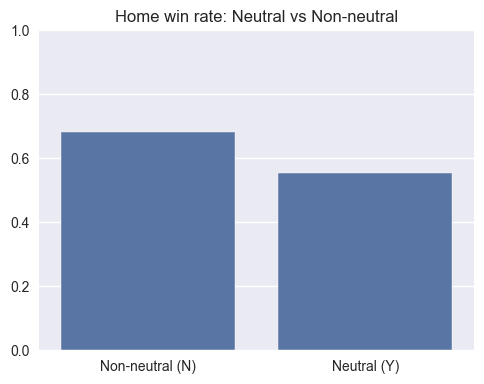


Margin (mean) Non-neutral: 8.363
Margin (mean) Neutral:     2.594
Mean diff (N - Y):         5.769
Cohen's d (N - Y):         0.367
Welch t-test p-value:      6.60655004395639e-24


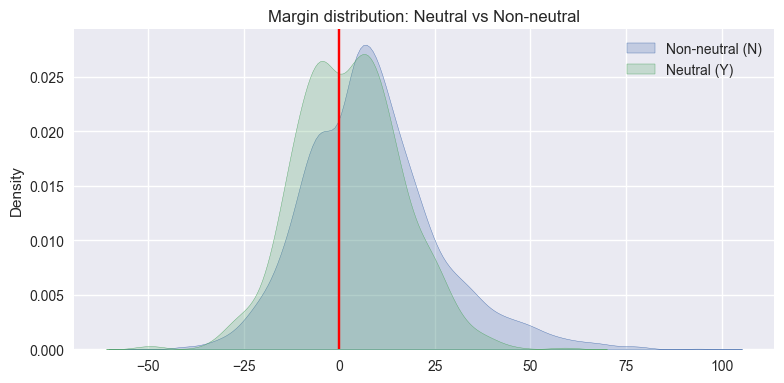


Margin (mean) No OT: 7.993
Margin (mean) OT:    -0.222
Mean diff (NoOT - OT): 8.215
Cohen's d (NoOT - OT): 0.596
Welch t-test p-value:   2.2352507762846222e-32


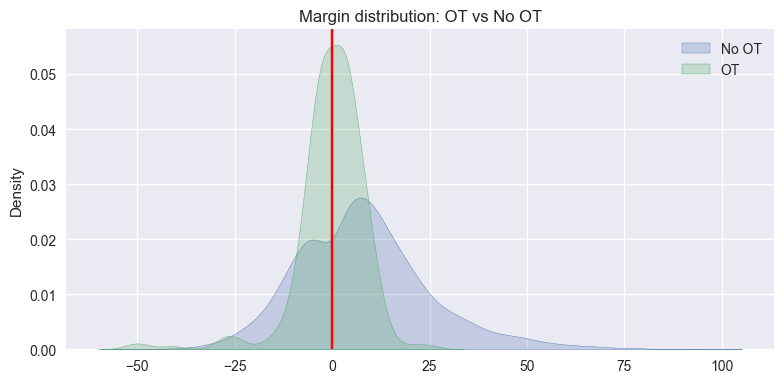

In [12]:
# =========================
# Step 5 — Quantify structural effects
# =========================

def cohens_d(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    a = a[~np.isnan(a)]
    b = b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    s = np.sqrt(((a.std(ddof=1) ** 2) + (b.std(ddof=1) ** 2)) / 2)
    if s == 0:
        return np.nan
    return (a.mean() - b.mean()) / s

def ttest_report(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    a = a[~np.isnan(a)]
    b = b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2:
        return (np.nan, np.nan)
    t, p = ttest_ind(a, b, equal_var=False)
    return (t, p)

# --- 1) Home win rate: Neutral vs Non-neutral ---
wr_N = g[g["neutral2"] == "N"]["home_win"].mean()
wr_Y = g[g["neutral2"] == "Y"]["home_win"].mean()

print("Home win rate (Non-neutral N):", round(float(wr_N), 4))
print("Home win rate (Neutral Y):    ", round(float(wr_Y), 4))
print("Difference (N - Y):           ", round(float(wr_N - wr_Y), 4))

plt.figure(figsize=(5,4))
sns.barplot(x=["Non-neutral (N)", "Neutral (Y)"], y=[wr_N, wr_Y])
plt.title("Home win rate: Neutral vs Non-neutral")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# --- 2) Margin: Neutral vs Non-neutral ---
m_N = g[g["neutral2"] == "N"]["margin"].values
m_Y = g[g["neutral2"] == "Y"]["margin"].values

d_margin = cohens_d(m_N, m_Y)
t_stat, p_val = ttest_report(m_N, m_Y)

print("\nMargin (mean) Non-neutral:", round(float(np.nanmean(m_N)), 3))
print("Margin (mean) Neutral:    ", round(float(np.nanmean(m_Y)), 3))
print("Mean diff (N - Y):        ", round(float(np.nanmean(m_N) - np.nanmean(m_Y)), 3))
print("Cohen's d (N - Y):        ", round(float(d_margin), 3))
print("Welch t-test p-value:     ", p_val)

plt.figure(figsize=(8,4))
sns.kdeplot(m_N, label="Non-neutral (N)", fill=True)
sns.kdeplot(m_Y, label="Neutral (Y)", fill=True)
plt.axvline(0, color="red")
plt.title("Margin distribution: Neutral vs Non-neutral")
plt.legend()
plt.tight_layout()
plt.show()

# --- 3) Margin: OT vs No OT ---
m_no = g[g["ot_flag"] == "N"]["margin"].values
m_ot = g[g["ot_flag"] == "Y"]["margin"].values

d_ot = cohens_d(m_no, m_ot)
t_stat2, p_val2 = ttest_report(m_no, m_ot)

print("\nMargin (mean) No OT:", round(float(np.nanmean(m_no)), 3))
print("Margin (mean) OT:   ", round(float(np.nanmean(m_ot)), 3))
print("Mean diff (NoOT - OT):", round(float(np.nanmean(m_no) - np.nanmean(m_ot)), 3))
print("Cohen's d (NoOT - OT):", round(float(d_ot), 3))
print("Welch t-test p-value:  ", p_val2)

plt.figure(figsize=(8,4))
sns.kdeplot(m_no, label="No OT", fill=True)
sns.kdeplot(m_ot, label="OT", fill=True)
plt.axvline(0, color="red")
plt.title("Margin distribution: OT vs No OT")
plt.legend()
plt.tight_layout()
plt.show()

## Step 6 — Inspect Feature Tables (team_stats, elo, teams)

Before merging anything, we need to understand:

- What is the primary key?
- Is there season?
- Are stats per game or aggregated?
- Does elo contain pregame ratings?

We inspect structure + sample rows.

In [15]:
# =========================
# Step 6 — Inspect feature tables (TRULY IOPub-safe)
# =========================

def inspect_df_safe(name, df, top_missing=15, preview_rows=2, preview_cols=12, max_cols_print=60):
    print("\n" + "="*90)
    print(f"{name}")
    print("Shape:", df.shape)
    print("Num columns:", df.shape[1])

    # ---------- Column printing (capped) ----------
    print("\nColumns:")
    total_cols = df.shape[1]

    if total_cols <= max_cols_print:
        for c in df.columns:
            print(" ", c)
    else:
        print(f"  Showing first {max_cols_print} of {total_cols} columns:")
        for c in df.columns[:max_cols_print]:
            print(" ", c)
        print("  ... (truncated)")

    # ---------- Dtypes ----------
    print("\nDtype counts:")
    print(df.dtypes.value_counts())

    # ---------- Missingness ----------
    miss = df.isna().mean().sort_values(ascending=False).head(top_missing)
    miss = miss[miss > 0]

    print(f"\nTop missingness (fraction, up to {top_missing}):")
    if len(miss) == 0:
        print("  (no missing values detected)")
    else:
        for k, v in miss.items():
            print(f"  {k}: {v:.3f}")

    # ---------- Safe Preview ----------
    print(f"\nPreview: first {preview_rows} rows, first {preview_cols} columns")
    preview = df.iloc[:preview_rows, :min(preview_cols, total_cols)]
    display(preview)


# Run inspection
inspect_df_safe("teams", teams)
inspect_df_safe("team_stats", team_stats)
inspect_df_safe("elo", elo)


teams
Shape: (362, 3)
Num columns: 3

Columns:
  code
  name
  location

Dtype counts:
str    3
Name: count, dtype: int64

Top missingness (fraction, up to 15):
  location: 0.970

Preview: first 2 rows, first 12 columns


,code,name,location
0,ACU,Abilene Christian Wildcats,NaN
1,AFA,Air Force Falcons,NaN



team_stats
Shape: (410, 57)
Num columns: 57

Columns:
  team_name
  team_code
  2fa
  2fa_d
  2fm
  2fm_d
  3fa
  3fa_d
  3fm
  3fm_d
  apg
  ast
  ast_d
  blk
  blk_d
  bpg
  confl
  confpct
  confw
  d_ppp
  dreb
  dreb_d
  f
  f_d
  fga
  fga_d
  fgm
  fgm_d
  fpg
  fta
  fta_d
  ftm
  ftm_d
  g
  l
  min
  min_d
  o_ppp
  oreb
  oreb_d
  pa
  pf
  pace
  poss
  reb
  reb_d
  rpg
  rpi
  sos
  spg
  stl
  stl_d
  to
  to_d
  topg
  w
  winpct

Dtype counts:
str       55
object     2
Name: count, dtype: int64

Top missingness (fraction, up to 15):
  sos: 1.000
  rpi: 1.000
  fgm_d: 0.756
  fpg: 0.739
  topg: 0.732
  spg: 0.729
  l: 0.727
  to_d: 0.724
  fta_d: 0.722
  f: 0.722
  stl: 0.722
  ftm_d: 0.720
  bpg: 0.720
  confl: 0.720
  rpg: 0.712

Preview: first 2 rows, first 12 columns


,team_name,team_code,2fa,2fa_d,2fm,2fm_d,3fa,3fa_d,3fm,3fm_d,apg,ast
0,Abilene Christian Wildcats,ACU,1457,1311,681,689,NaN,NaN,NaN,NaN,NaN,NaN
1,Air Force Falcons,AFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.5,NaN



elo
Shape: (362, 244529)
Num columns: 244529

Columns:
  Showing first 60 of 244529 columns:
  team
  code
  elo
  elorank
  lastgamegame_1489064id
  lastgamegame_1489064gameday
  lastgamegame_1489064visitor_code
  lastgamegame_1489064visitor
  lastgamegame_1489064scorevis
  lastgamegame_1489064home_code
  lastgamegame_1489064home
  lastgamegame_1489064scorehome
  lastgamegame_1489064gamestatus
  lastgamegame_1489064winorloss
  lastgamegame_1489064elo_beforegame
  lastgamegame_1489064elo_change
  lastgamegame_1489064elo_kfactor
  lastgamegame_1489064elo_adjust
  lastgamegame_1489064elo_winexpectancy
  lastgamegame_1489064forecast_favorite_code
  lastgamegame_1489064forecast_favorite
  dailydaily_3635723date
  dailydaily_3635723elo
  dailydaily_3635723elorank
  dailydaily_3635723lastgame_id
  dailydaily_3635723seasongames
  dailydaily_3635723gameid
  dailydaily_3635723gamegameday
  dailydaily_3635723gamevisitor_code
  dailydaily_3635723gamevisitor
  dailydaily_3635723gamescorevis
  dai

,team,code,elo,elorank,lastgamegame_1489064id,lastgamegame_1489064gameday,lastgamegame_1489064visitor_code,lastgamegame_1489064visitor,lastgamegame_1489064scorevis,lastgamegame_1489064home_code,lastgamegame_1489064home,lastgamegame_1489064scorehome
0,Duke,DUKE,2123,1,1489064,2026-02-24,DUKE,Duke,100,ND,Notre Dame,56
1,Florida,FLA,2079,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# =========================
# Step 7 — Clean ELO table (KEEP ONLY CURRENT RATINGS)
# =========================

print("Original elo shape:", elo.shape)

# Keep only useful columns
elo_clean = elo[["code", "elo", "elorank"]].copy()

# Convert to numeric
elo_clean["elo"] = pd.to_numeric(elo_clean["elo"], errors="coerce")
elo_clean["elorank"] = pd.to_numeric(elo_clean["elorank"], errors="coerce")

print("Cleaned elo shape:", elo_clean.shape)
display(elo_clean.head())

Original elo shape: (362, 244529)
Cleaned elo shape: (362, 3)


,code,elo,elorank
0,DUKE,2123,1
1,FLA,2079,2
2,HOU,2055,3
3,ARIZ,2046,4
4,CONN,2043,5


In [17]:
# =========================
# Step 8 — Clean team_stats numerics
# =========================

team_stats_clean = team_stats.copy()

# Keep only useful columns (avoid 99% missing junk)
keep_cols = [
    "team_code",
    "o_ppp", "d_ppp",
    "pace",
    "reb", "reb_d",
    "oreb", "dreb",
    "to", "to_d",
    "fgm", "fga",
    "ftm", "fta",
    "winpct"
]

team_stats_clean = team_stats_clean[keep_cols]

# Convert everything except team_code to numeric
for c in team_stats_clean.columns:
    if c != "team_code":
        team_stats_clean[c] = pd.to_numeric(team_stats_clean[c], errors="coerce")

print("Cleaned team_stats shape:", team_stats_clean.shape)
display(team_stats_clean.head())

Cleaned team_stats shape: (410, 15)


,team_code,o_ppp,d_ppp,pace,reb,reb_d,oreb,dreb,to,to_d,fgm,fga,ftm,fta,winpct
0,ACU,NaN,NaN,73.9,NaN,1170.0,NaN,NaN,419.0,472.0,NaN,NaN,550.0,757.0,NaN
1,AFA,NaN,1.109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AKR,NaN,NaN,NaN,1145.0,NaN,NaN,837.0,NaN,NaN,915.0,2015.0,NaN,NaN,0.706
3,ALAM,NaN,NaN,75.0,1123.0,1142.0,329.0,NaN,535.0,463.0,NaN,NaN,654.0,906.0,NaN
4,ALA,1.189,1.069,77.5,1333.0,1184.0,407.0,926.0,429.0,401.0,1136.0,2384.0,650.0,842.0,0.656


In [18]:
# =========================
# Step 9 — Build modeling table
# =========================

model_df = games.copy()

# --- Merge home stats ---
model_df = model_df.merge(
    team_stats_clean,
    left_on="home_code",
    right_on="team_code",
    how="left",
    suffixes=("", "_home")
)

# Rename merged columns
for col in team_stats_clean.columns:
    if col != "team_code":
        model_df.rename(columns={col: col + "_home"}, inplace=True)

model_df.drop(columns=["team_code"], inplace=True)

# --- Merge visitor stats ---
model_df = model_df.merge(
    team_stats_clean,
    left_on="visitor_code",
    right_on="team_code",
    how="left",
    suffixes=("", "_vis")
)

for col in team_stats_clean.columns:
    if col != "team_code":
        model_df.rename(columns={col: col + "_vis"}, inplace=True)

model_df.drop(columns=["team_code"], inplace=True)

# --- Merge home ELO ---
model_df = model_df.merge(
    elo_clean,
    left_on="home_code",
    right_on="code",
    how="left"
)

model_df.rename(columns={"elo": "elo_home"}, inplace=True)
model_df.drop(columns=["code", "elorank"], inplace=True)

# --- Merge visitor ELO ---
model_df = model_df.merge(
    elo_clean,
    left_on="visitor_code",
    right_on="code",
    how="left"
)

model_df.rename(columns={"elo": "elo_vis"}, inplace=True)
model_df.drop(columns=["code", "elorank"], inplace=True)

print("Final modeling df shape:", model_df.shape)
display(model_df.head())

Final modeling df shape: (8171, 47)


,id,visitor,visitor_code,score_vis,home,home_code,score_home,gamestatus,overtime,winner_code,...,dreb_vis,to_vis,to_d_vis,fgm_vis,fga_vis,ftm_vis,fta_vis,winpct_vis,elo_home,elo_vis
0,1259345,Purdue Boilermakers,PUR,60,Connecticut Huskies,CONN,75,Final,N,CONN,...,1044.0,422.0,NaN,1109.0,2272.0,675.0,938.0,0.879,2043.0,1923.0
1,1259345,Purdue Boilermakers,PUR,60,Connecticut Huskies,CONN,75,Final,N,CONN,...,1044.0,422.0,NaN,1109.0,2272.0,675.0,938.0,0.879,2043.0,1923.0
2,1259340,North Carolina State Wolfpack,NCSU,50,Purdue Boilermakers,PUR,63,Final,N,PUR,...,985.0,NaN,463.0,1117.0,2485.0,582.0,794.0,NaN,1923.0,1684.0
3,1259340,North Carolina State Wolfpack,NCSU,50,Purdue Boilermakers,PUR,63,Final,N,PUR,...,985.0,NaN,463.0,1117.0,2485.0,582.0,794.0,NaN,1923.0,1684.0
4,1259340,North Carolina State Wolfpack,NCSU,50,Purdue Boilermakers,PUR,63,Final,N,PUR,...,985.0,NaN,463.0,1117.0,2485.0,582.0,794.0,NaN,1923.0,1684.0


In [19]:
# =========================
# Step 10 — Deduplicate games properly
# =========================

print("Rows before dedupe:", model_df.shape[0])

# Keep only Final games
model_df = model_df[model_df["gamestatus"] == "Final"].copy()

# Drop duplicate game IDs
model_df = model_df.drop_duplicates(subset=["id"])

print("Rows after dedupe:", model_df.shape[0])
display(model_df.head())

Rows before dedupe: 8171
Rows after dedupe: 5900


,id,visitor,visitor_code,score_vis,home,home_code,score_home,gamestatus,overtime,winner_code,...,dreb_vis,to_vis,to_d_vis,fgm_vis,fga_vis,ftm_vis,fta_vis,winpct_vis,elo_home,elo_vis
0,1259345,Purdue Boilermakers,PUR,60,Connecticut Huskies,CONN,75,Final,N,CONN,...,1044.0,422.0,NaN,1109.0,2272.0,675.0,938.0,0.879,2043.0,1923.0
2,1259340,North Carolina State Wolfpack,NCSU,50,Purdue Boilermakers,PUR,63,Final,N,PUR,...,985.0,NaN,463.0,1117.0,2485.0,582.0,794.0,NaN,1923.0,1684.0
6,1259338,Alabama Crimson Tide,ALA,72,Connecticut Huskies,CONN,86,Final,N,CONN,...,926.0,429.0,401.0,1136.0,2384.0,650.0,842.0,0.656,2043.0,1949.0
8,1259343,Indiana State Sycamores,INST,77,Seton Hall Pirates,SETON,79,Final,N,SETON,...,1039.0,438.0,401.0,1141.0,2258.0,600.0,754.0,0.821,1567.0,1201.0
12,1259330,Georgia Bulldogs,UGA,67,Seton Hall Pirates,SETON,84,Final,N,SETON,...,885.0,408.0,407.0,943.0,2194.0,577.0,803.0,NaN,1567.0,1708.0


In [20]:
# =========================
# Step 11 — Feature engineering
# =========================

model_df["home_win"] = (model_df["winner_code"] == model_df["home_code"]).astype(int)

model_df["elo_diff"] = model_df["elo_home"] - model_df["elo_vis"]
model_df["ppp_diff"] = model_df["o_ppp_home"] - model_df["o_ppp_vis"]
model_df["pace_diff"] = model_df["pace_home"] - model_df["pace_vis"]
model_df["winpct_diff"] = model_df["winpct_home"] - model_df["winpct_vis"]

display(model_df[[
    "home_win",
    "elo_diff",
    "ppp_diff",
    "pace_diff",
    "winpct_diff"
]].head())

,home_win,elo_diff,ppp_diff,pace_diff,winpct_diff
0,1,120.0,0.039,NaN,0.033
2,1,239.0,NaN,NaN,NaN
6,1,94.0,0.033,NaN,0.256
8,1,366.0,NaN,NaN,-0.145
12,1,-141.0,NaN,NaN,NaN


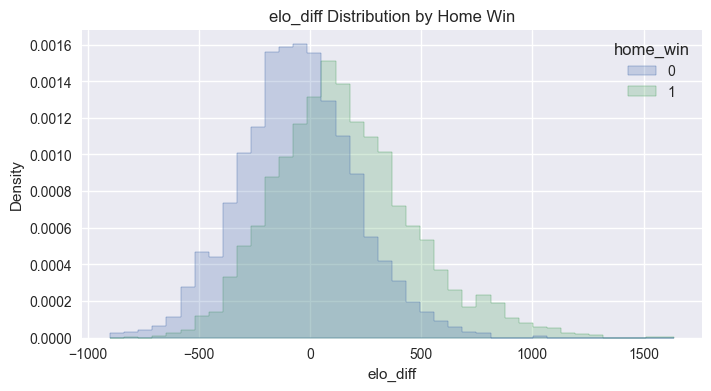

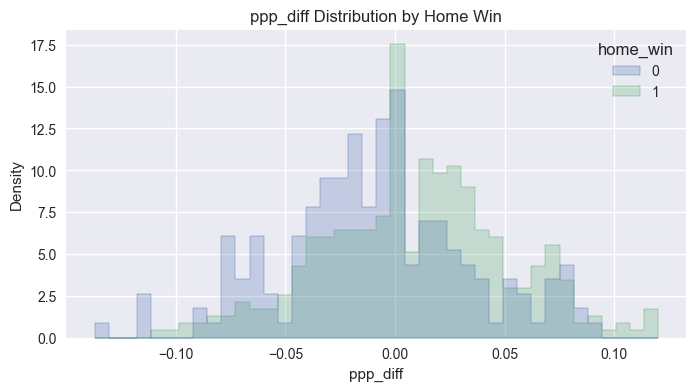

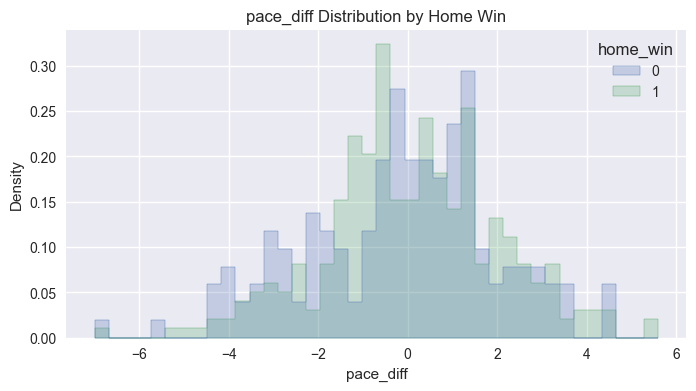

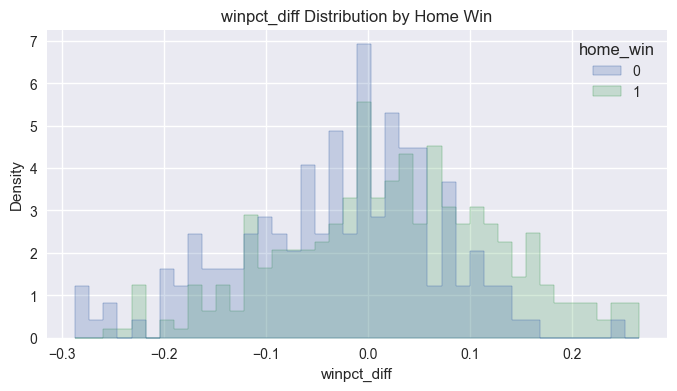

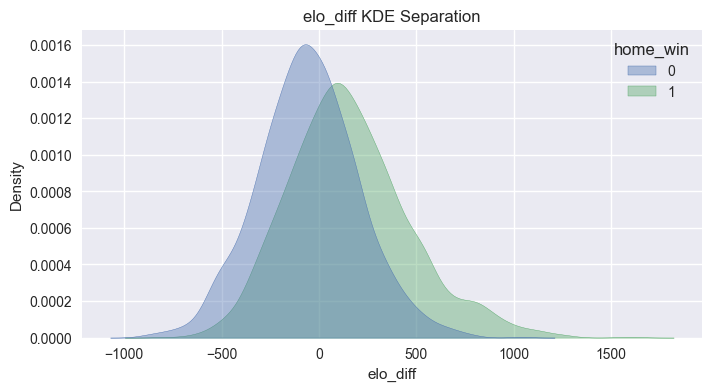

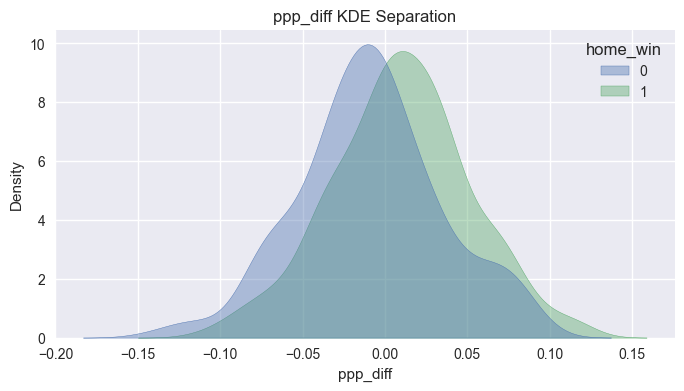

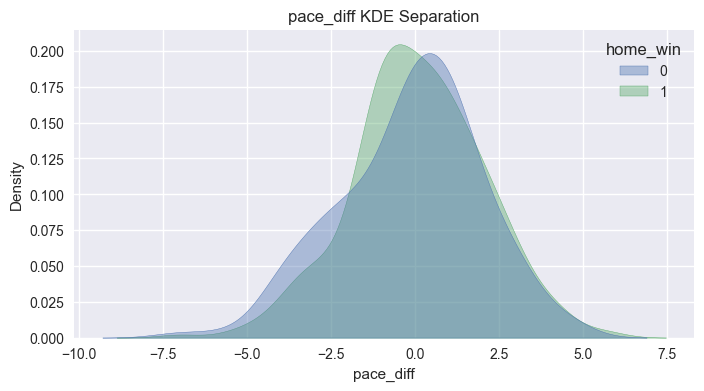

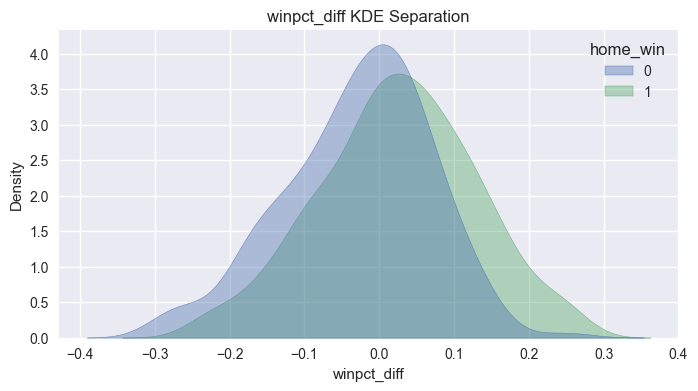

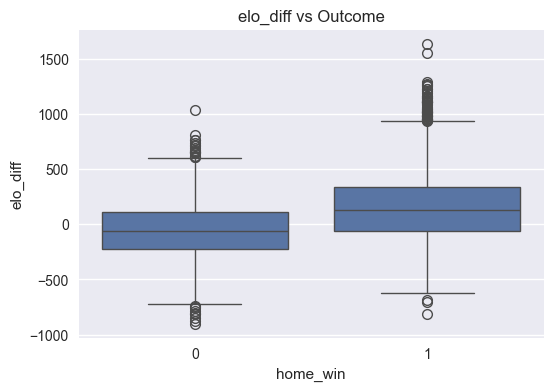

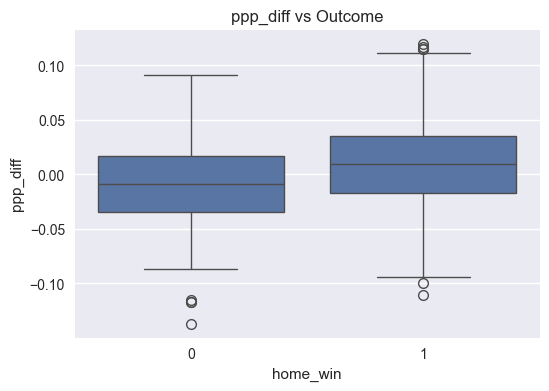

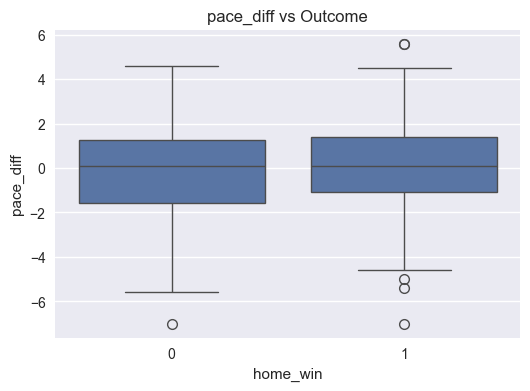

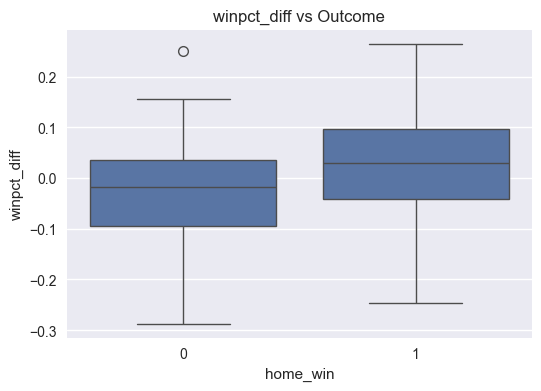


=== Statistical Separation ===

elo_diff
Mean diff (win - loss): 210.9254
Cohen's d: 0.734
Welch p-value: 7.534e-145

ppp_diff
Mean diff (win - loss): 0.0187
Cohen's d: 0.436
Welch p-value: 2.972e-06

pace_diff
Mean diff (win - loss): 0.2237
Cohen's d: 0.110
Welch p-value: 2.637e-01

winpct_diff
Mean diff (win - loss): 0.0535
Cohen's d: 0.527
Welch p-value: 1.416e-08


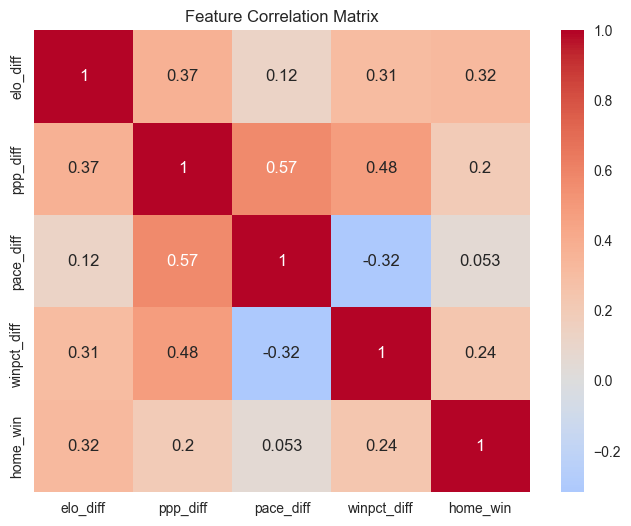

In [21]:
# =========================
# Step 12 — Feature Distribution & Separation (Pure EDA)
# =========================

feature_cols = [
    "elo_diff",
    "ppp_diff",
    "pace_diff",
    "winpct_diff"
]

# -------------------------
# 1️⃣ Histograms (by outcome)
# -------------------------

for col in feature_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(
        data=model_df,
        x=col,
        hue="home_win",
        bins=40,
        element="step",
        stat="density",
        common_norm=False
    )
    plt.title(f"{col} Distribution by Home Win")
    plt.show()

# -------------------------
# 2️⃣ KDE Overlays
# -------------------------

for col in feature_cols:
    plt.figure(figsize=(8,4))
    sns.kdeplot(
        data=model_df,
        x=col,
        hue="home_win",
        fill=True,
        common_norm=False,
        alpha=0.4
    )
    plt.title(f"{col} KDE Separation")
    plt.show()

# -------------------------
# 3️⃣ Boxplots
# -------------------------

for col in feature_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=model_df, x="home_win", y=col)
    plt.title(f"{col} vs Outcome")
    plt.show()

# -------------------------
# 4️⃣ Statistical Separation
# -------------------------

print("\n=== Statistical Separation ===")

for col in feature_cols:
    wins = model_df.loc[model_df["home_win"] == 1, col].dropna()
    losses = model_df.loc[model_df["home_win"] == 0, col].dropna()

    mean_diff = wins.mean() - losses.mean()
    t_stat, p_val = ttest_ind(wins, losses, equal_var=False)

    pooled_std = np.sqrt((wins.var() + losses.var()) / 2)
    cohens_d = mean_diff / pooled_std

    print(f"\n{col}")
    print(f"Mean diff (win - loss): {mean_diff:.4f}")
    print(f"Cohen's d: {cohens_d:.3f}")
    print(f"Welch p-value: {p_val:.3e}")

# -------------------------
# 5️⃣ Correlation Matrix
# -------------------------

plt.figure(figsize=(8,6))
corr = model_df[feature_cols + ["home_win"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

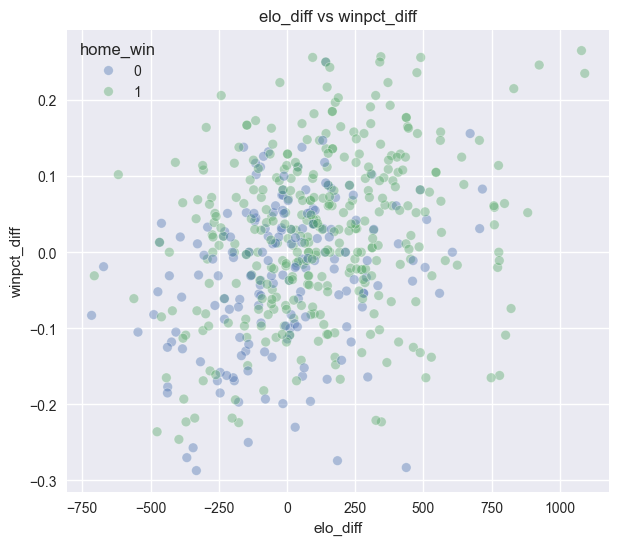

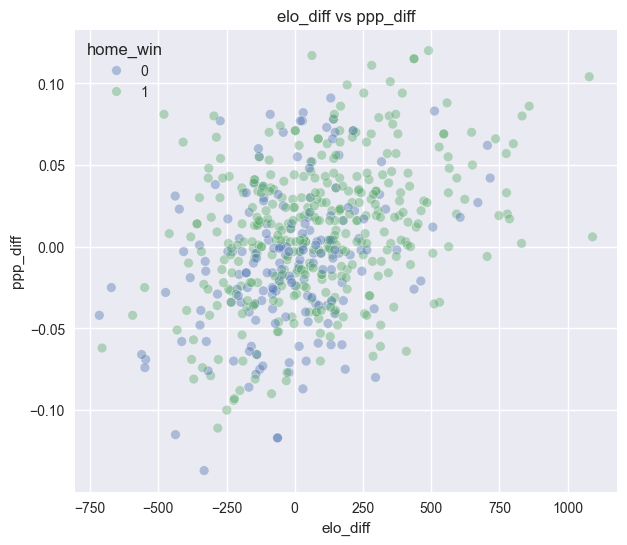

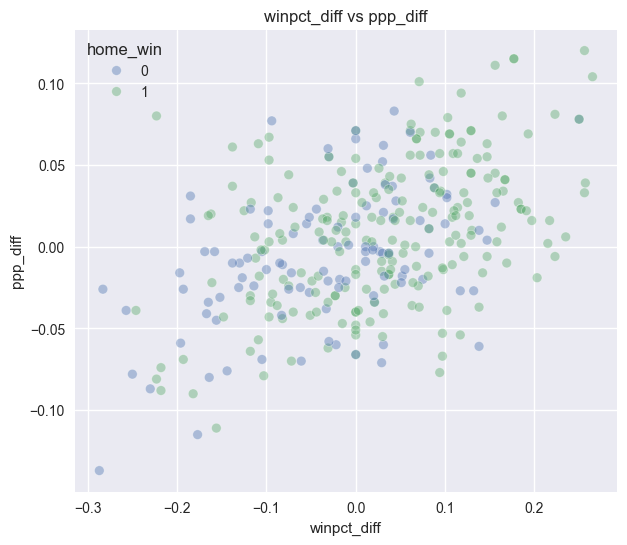

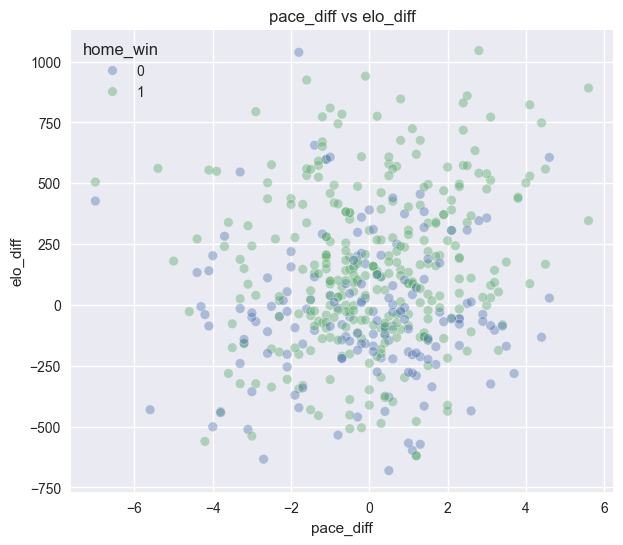

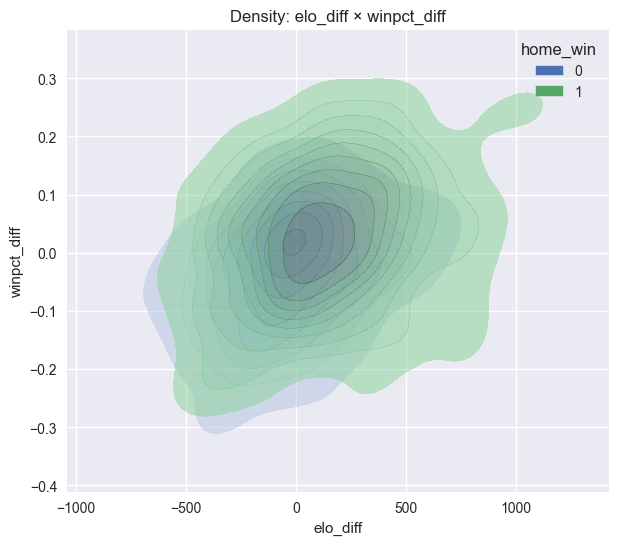

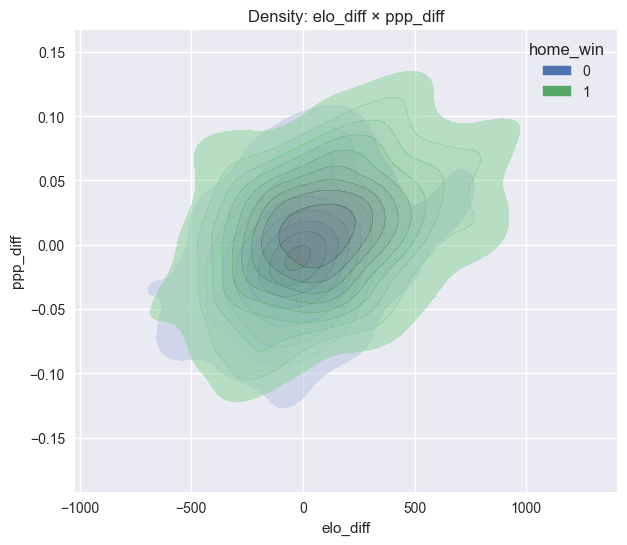

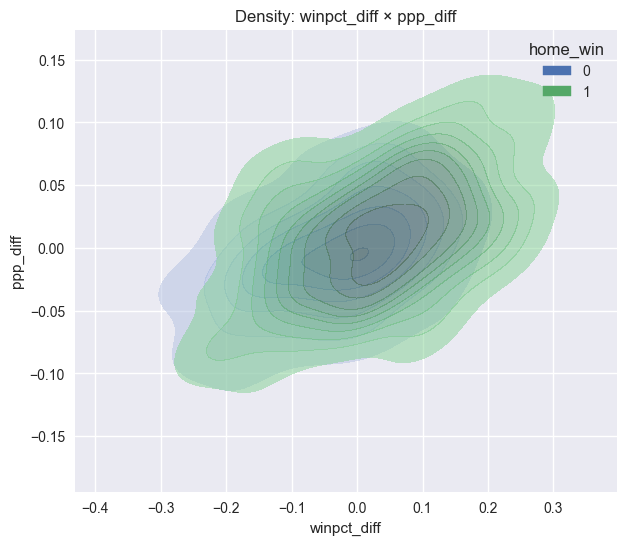

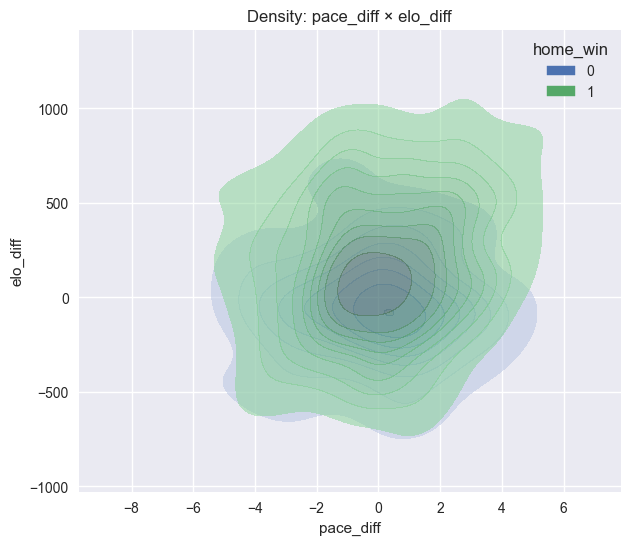

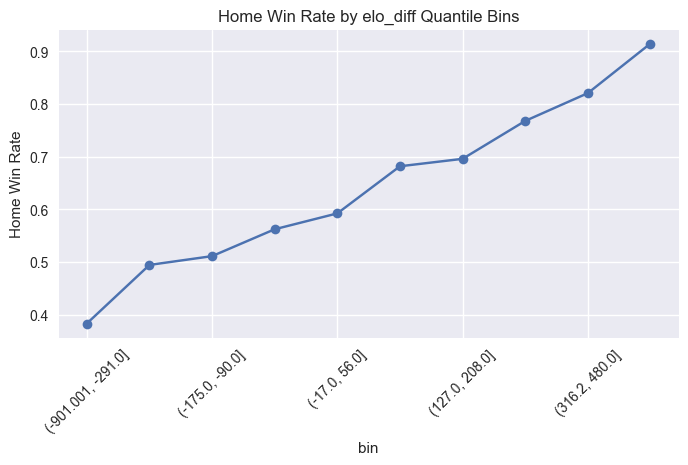

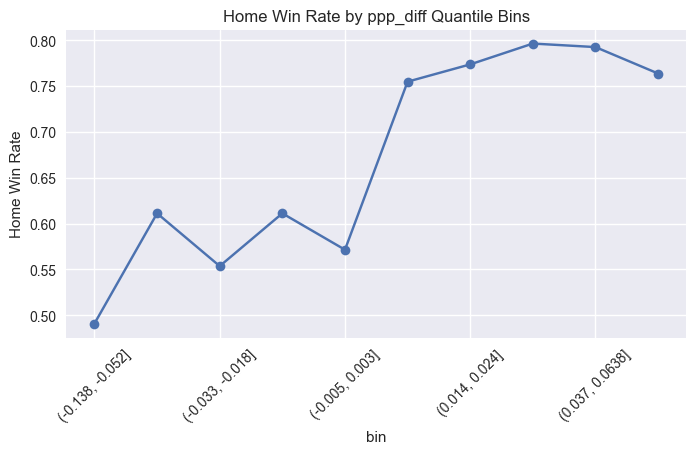

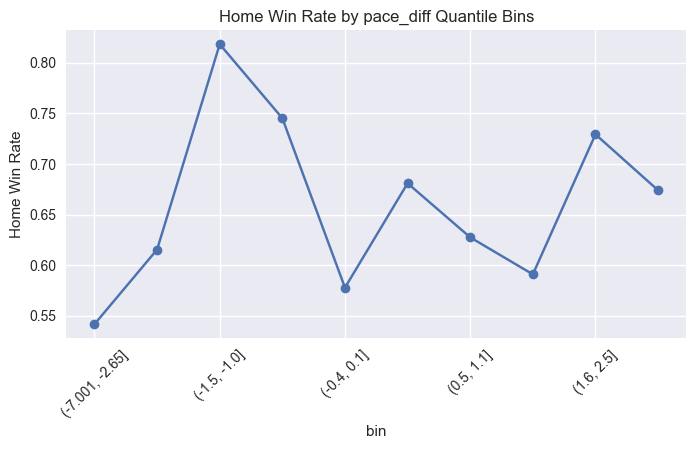

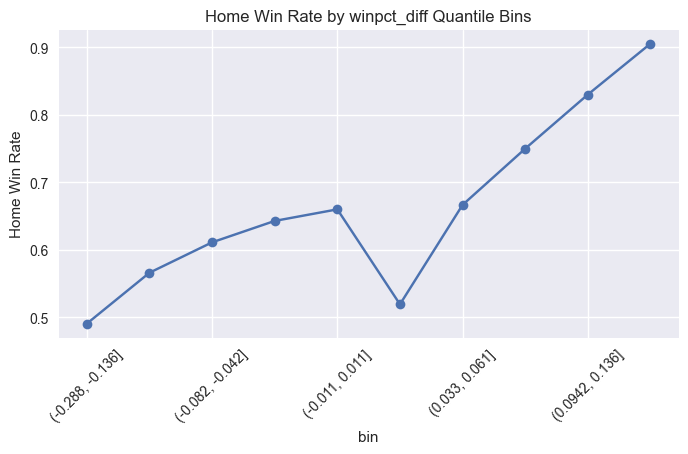

In [22]:
# =========================
# Step 13 — Feature Interactions & Nonlinearity
# =========================

interaction_pairs = [
    ("elo_diff", "winpct_diff"),
    ("elo_diff", "ppp_diff"),
    ("winpct_diff", "ppp_diff"),
    ("pace_diff", "elo_diff"),
]

# -------------------------
# 1️⃣ 2D Scatter (Outcome colored)
# -------------------------

for x_col, y_col in interaction_pairs:
    plt.figure(figsize=(7,6))
    sns.scatterplot(
        data=model_df,
        x=x_col,
        y=y_col,
        hue="home_win",
        alpha=0.4
    )
    plt.title(f"{x_col} vs {y_col}")
    plt.show()


# -------------------------
# 2️⃣ 2D KDE Density by Outcome
# -------------------------

for x_col, y_col in interaction_pairs:
    plt.figure(figsize=(7,6))
    sns.kdeplot(
        data=model_df,
        x=x_col,
        y=y_col,
        hue="home_win",
        fill=True,
        thresh=0.05,
        alpha=0.5
    )
    plt.title(f"Density: {x_col} × {y_col}")
    plt.show()


# -------------------------
# 3️⃣ Win Rate by Feature Bins (Monotonicity Check)
# -------------------------

def win_rate_by_bins(col, bins=10):
    df = model_df[[col, "home_win"]].dropna().copy()
    df["bin"] = pd.qcut(df[col], q=bins, duplicates="drop")
    summary = df.groupby("bin")["home_win"].mean()

    plt.figure(figsize=(8,4))
    summary.plot(marker="o")
    plt.xticks(rotation=45)
    plt.title(f"Home Win Rate by {col} Quantile Bins")
    plt.ylabel("Home Win Rate")
    plt.show()

for col in feature_cols:
    win_rate_by_bins(col, bins=10)

Margin summary:
count    5900.000000
mean        7.908305
std        17.345151
min       -51.000000
25%        -4.000000
50%         7.000000
75%        17.000000
max        96.000000
Name: margin, dtype: float64


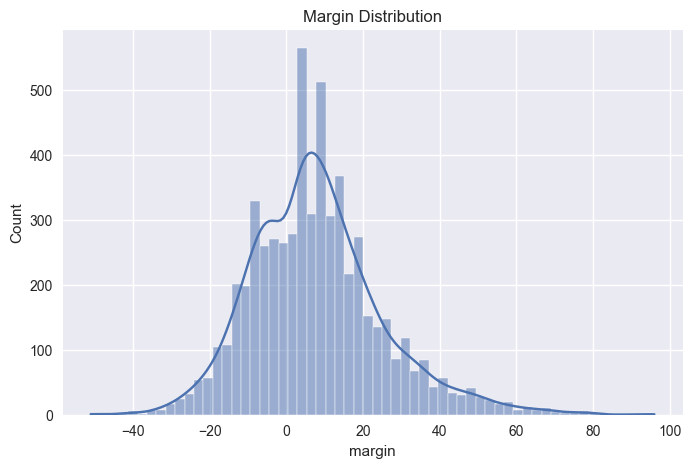

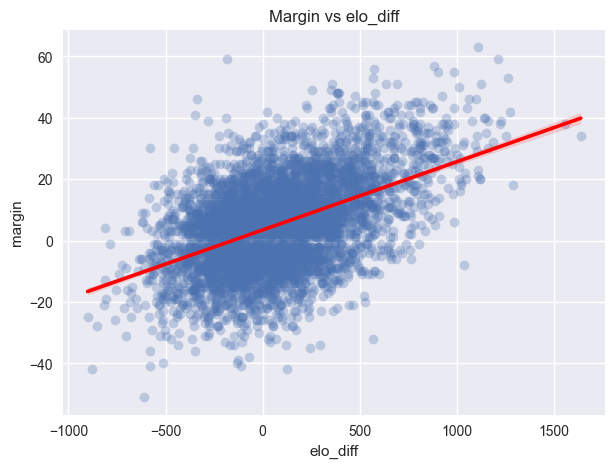

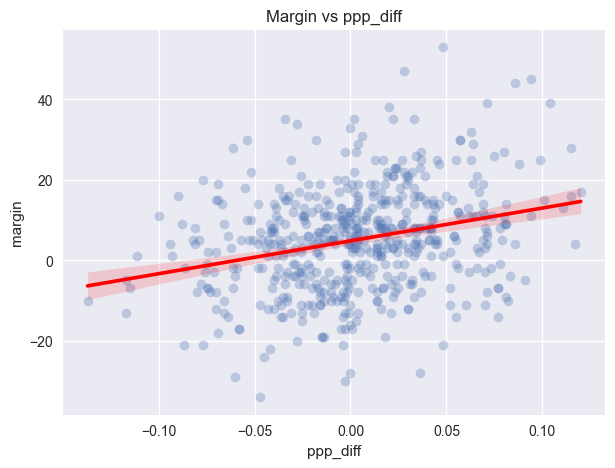

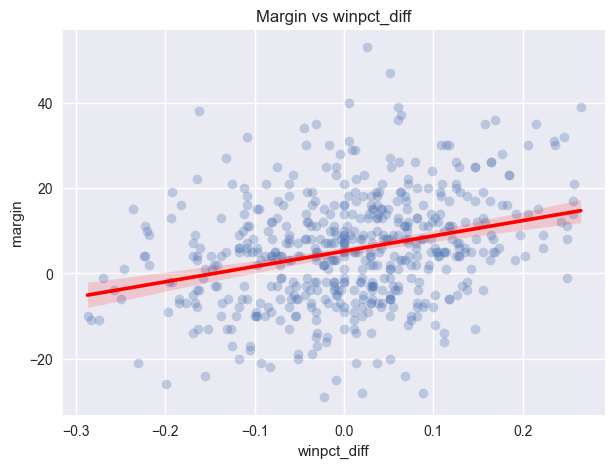

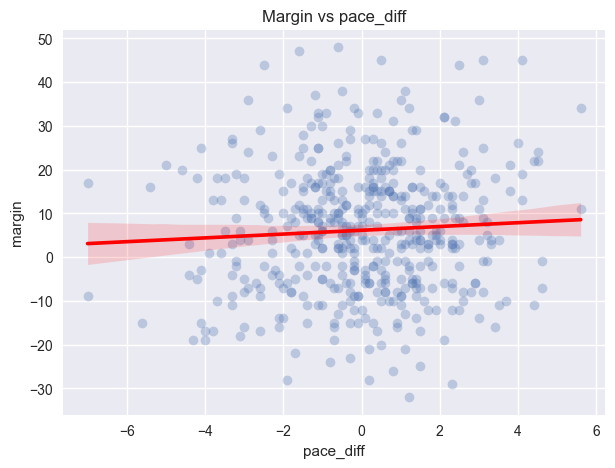

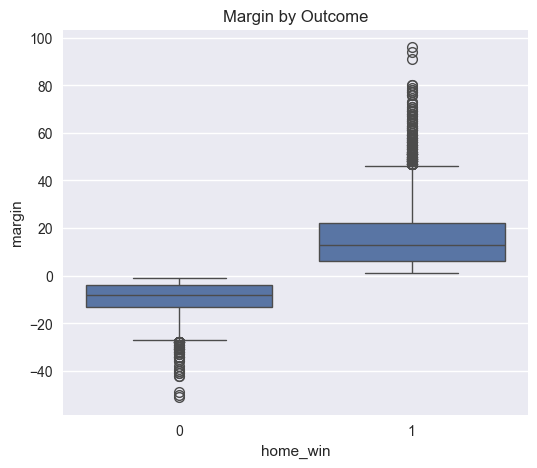

Margin Skew: 0.698
Margin Kurtosis: 1.310
Extreme margin games (>30 pts): 608


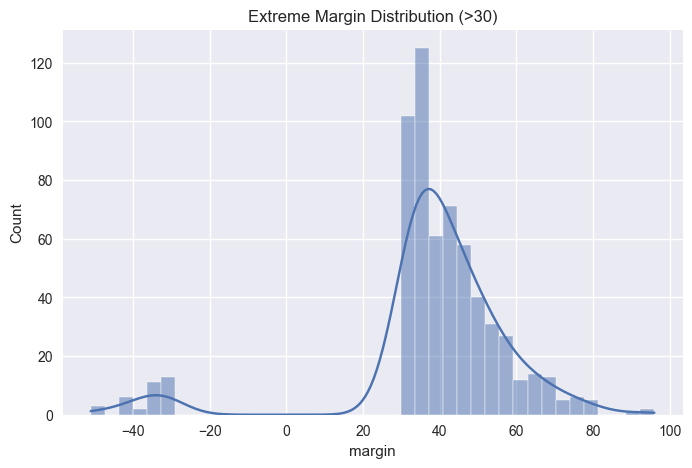

In [24]:
# =========================
# Step 14 — Continuous Margin Analysis (FULL SAFE VERSION)
# =========================

# ---- Ensure numeric score columns ----
model_df["score_home"] = pd.to_numeric(model_df["score_home"], errors="coerce")
model_df["score_vis"] = pd.to_numeric(model_df["score_vis"], errors="coerce")

# ---- Create margin if missing ----
if "margin" not in model_df.columns:
    model_df["margin"] = model_df["score_home"] - model_df["score_vis"]

print("Margin summary:")
print(model_df["margin"].describe())

# -------------------------
# 1️⃣ Margin Distribution
# -------------------------
plt.figure(figsize=(8,5))
sns.histplot(model_df["margin"].dropna(), bins=60, kde=True)
plt.title("Margin Distribution")
plt.show()

# -------------------------
# 2️⃣ Margin vs Diff Features
# -------------------------

diff_features = ["elo_diff", "ppp_diff", "winpct_diff", "pace_diff"]

for col in diff_features:
    if col in model_df.columns:
        plt.figure(figsize=(7,5))
        sns.regplot(
            data=model_df,
            x=col,
            y="margin",
            scatter_kws={"alpha":0.3},
            line_kws={"color":"red"}
        )
        plt.title(f"Margin vs {col}")
        plt.show()

# -------------------------
# 3️⃣ Margin by Outcome
# -------------------------

plt.figure(figsize=(6,5))
sns.boxplot(data=model_df, x="home_win", y="margin")
plt.title("Margin by Outcome")
plt.show()

# -------------------------
# 4️⃣ Margin Skew & Tail Diagnostics
# -------------------------

skew = model_df["margin"].skew()
kurt = model_df["margin"].kurtosis()

print(f"Margin Skew: {skew:.3f}")
print(f"Margin Kurtosis: {kurt:.3f}")

# Extreme margins
extreme_games = model_df[np.abs(model_df["margin"]) > 30]

print("Extreme margin games (>30 pts):", len(extreme_games))

plt.figure(figsize=(8,5))
sns.histplot(extreme_games["margin"], bins=40, kde=True)
plt.title("Extreme Margin Distribution (>30)")
plt.show()

PCA sample size: 41
Explained variance ratio: [0.55315999 0.22011164]


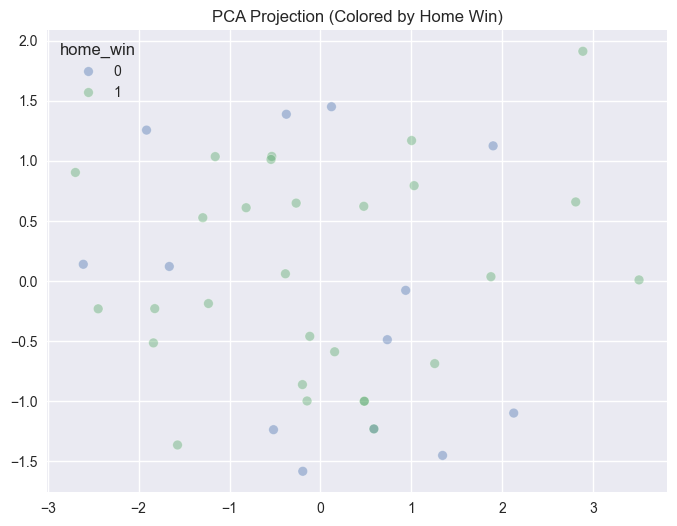


PCA Loadings:


,PC1,PC2
elo_diff,0.391835,0.726426
ppp_diff,0.489239,-0.635742
pace_diff,0.623437,-0.128151
winpct_diff,-0.467373,-0.227409


In [25]:
# =========================
# Step 15 — PCA Structure Analysis (Full Safe)
# =========================

pca_features = ["elo_diff", "ppp_diff", "pace_diff", "winpct_diff"]

# Keep only rows with all features present
pca_df = model_df[pca_features + ["home_win"]].dropna().copy()

print("PCA sample size:", len(pca_df))

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df[pca_features])

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Scatter
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=pca_df["home_win"],
    alpha=0.4
)
plt.title("PCA Projection (Colored by Home Win)")
plt.show()

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=["PC1", "PC2"]
)

print("\nPCA Loadings:")
display(loadings)

Silhouette Score: 0.2191279665054858


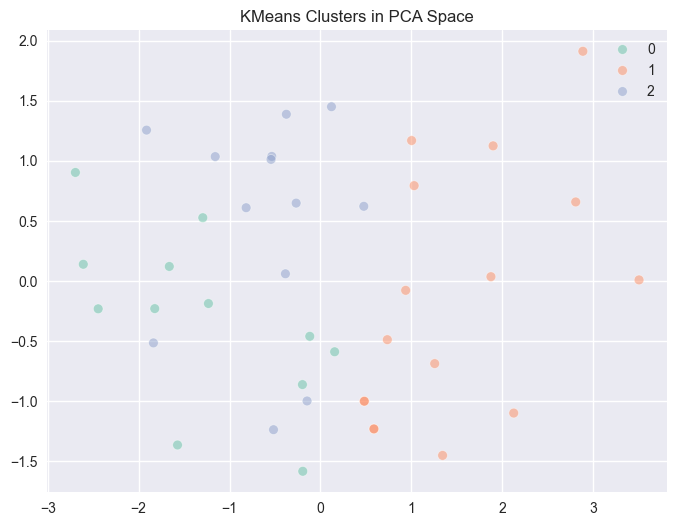


Win rate by cluster:
cluster
0    0.750000
1    0.625000
2    0.692308
Name: home_win, dtype: float64


In [26]:
# =========================
# Step 16 — Unsupervised Regime Detection
# =========================

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

print("Silhouette Score:", silhouette_score(X_scaled, clusters))

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters,
    palette="Set2",
    alpha=0.5
)
plt.title("KMeans Clusters in PCA Space")
plt.show()

# Cluster win rates
cluster_df = pca_df.copy()
cluster_df["cluster"] = clusters

cluster_summary = cluster_df.groupby("cluster")["home_win"].mean()

print("\nWin rate by cluster:")
print(cluster_summary)

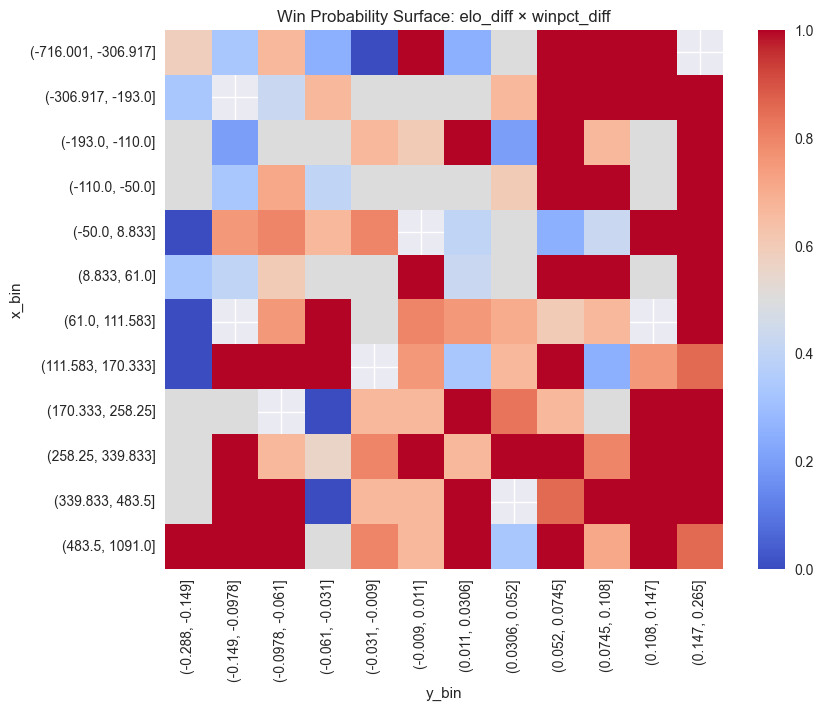

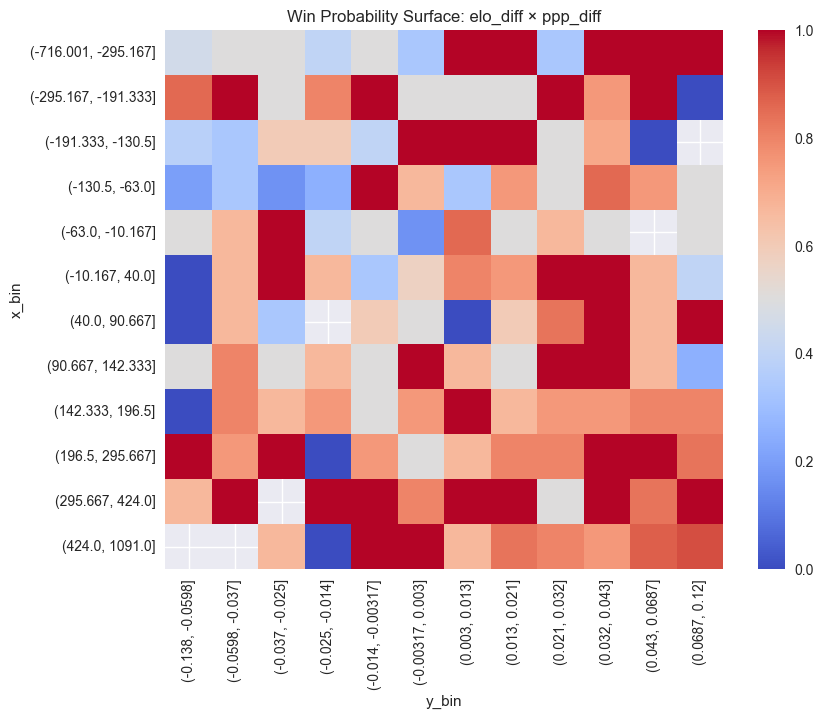

In [27]:
# =========================
# Step 17 — 2D Conditional Win Probability Surface
# =========================

def probability_surface(x_col, y_col, bins=12):
    df = model_df[[x_col, y_col, "home_win"]].dropna().copy()

    df["x_bin"] = pd.qcut(df[x_col], q=bins, duplicates="drop")
    df["y_bin"] = pd.qcut(df[y_col], q=bins, duplicates="drop")

    pivot = df.groupby(["x_bin", "y_bin"])["home_win"].mean().unstack()

    plt.figure(figsize=(9,7))
    sns.heatmap(pivot, cmap="coolwarm", center=0.5)
    plt.title(f"Win Probability Surface: {x_col} × {y_col}")
    plt.show()

probability_surface("elo_diff", "winpct_diff")
probability_surface("elo_diff", "ppp_diff")

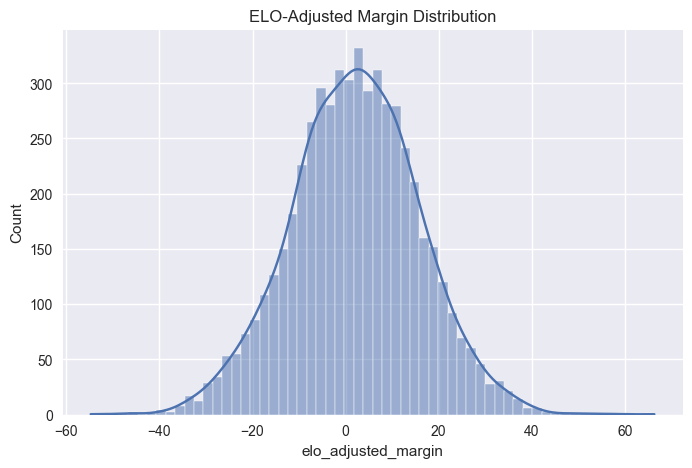

Mean adjusted margin: 2.048690166975881


In [28]:
# =========================
# Step 18 — Residual Home Advantage After Adjustment
# =========================

# Adjust margin for ELO expectation (approx scaling)
model_df["elo_adjusted_margin"] = model_df["margin"] - model_df["elo_diff"]/25

plt.figure(figsize=(8,5))
sns.histplot(model_df["elo_adjusted_margin"].dropna(), bins=60, kde=True)
plt.title("ELO-Adjusted Margin Distribution")
plt.show()

print("Mean adjusted margin:", model_df["elo_adjusted_margin"].mean())